# WildWatch sleep pattern analysis

You work as a data analyst at **WildWatch Research Institute**, a conservation organization studying animal behavior across different ecosystems.

<img src="" alt=""/>

The behavioral ecology team has collected comprehensive sleep data from 83 mammal species over the past three years. They need statistical insights to understand sleep patterns, identify unusual behaviors, and explore relationships between physical characteristics and rest requirements.

Your department head wants a rigorous statistical analysis before presenting findings at the International Wildlife Conservation Summit next month. The research will inform habitat management strategies and species protection priorities.

The dataset includes the following columns:

| Column | Description | Example |
|--------|-------------|---------|
| `name` | Common name of the mammal | African elephant, Cat, Human |
| `genus` | Taxonomic genus | Afr, Cat, Hum |
| `vore` | Diet type (carnivore, herbivore, omnivore, insectivore) | herbivore, carnivore, omnivore |
| `order` | Taxonomic order | Proboscidea, Carnivora, Primates |
| `conservation` | Conservation status (lc, nt, vu, en, cd) | lc, vu, en |
| `sleep_total` | Total hours of sleep per day | 3.3, 12.5, 8.0 |
| `sleep_rem` | REM sleep hours per day | 0.5, 3.2, 1.9 |
| `sleep_cycle` | Length of sleep cycle in hours | 0.13, 0.42, 1.5 |
| `awake` | Hours awake per day | 20.7, 11.5, 16.0 |
| `brainwt` | Brain weight in kilograms | 5.16, 0.0256, 1.32 |
| `bodywt` | Body weight in kilograms | 6654, 3.3, 62 |


<Note type = "important">

The dataset `msleep.csv` is available in the resources section

</Note>

## Your mission

Your goal is to produce a **comprehensive statistical report** that characterizes mammal sleep patterns, identifies behavioral outliers, and uncovers relationships between physiological traits and rest requirements. 

The analysis must follow **rigorous statistical principles** and provide actionable insights for conservation priorities.

## Analysis Tasks


In [79]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid", palette="muted", context="notebook")

# Load the dataset
df = pd.read_csv('msleep.csv')
df_test_summary_function = pd.read_csv('database.csv')

print("="*80)
print("WILDWATCH RESEARCH INSTITUTE - SLEEP PATTERN ANALYSIS")
print("="*80)
print("\nDataset Overview:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

WILDWATCH RESEARCH INSTITUTE - SLEEP PATTERN ANALYSIS

Dataset Overview:
                   name genus         vore           order conservation  \
0      African elephant   Afr    herbivore     Proboscidea           vu   
1      Asiatic elephant   Asi    herbivore     Proboscidea           en   
2         Big brown bat   Big  insectivore      Chiroptera           lc   
3  Bottle-nosed dolphin   Bot    carnivore         Cetacea           lc   
4       Brazilian tapir   Bra    herbivore  Perissodactyla           vu   

   sleep_total  sleep_rem  sleep_cycle  awake  brainwt    bodywt  
0          3.3        0.5          NaN   20.7   5.1600  6654.000  
1          3.9        0.6          NaN   20.1   4.6000  2547.000  
2         19.7        3.9         0.13    4.3   0.0003     0.023  
3          5.2        NaN         0.90   18.8   1.3200   173.500  
4          4.4        1.0         0.90   19.6   0.1690   160.000  

Dataset shape: (83, 11)

Column types:
name             object
genus     

### Task 1: Central tendency analysis

- Calculate the mean, median, and mode for `sleep_total` across all mammals in the dataset. The research team needs to understand what constitutes "typical" sleep behavior for mammals.

- Determine which measure of central tendency best represents typical mammal sleep patterns. Write a brief explanation (2-3 sentences) justifying your choice based on the distribution characteristics you observe.
- Plotte a histogram of `sleep_total` to visualize the distribution of sleep duration.

In [ ]:
# ============================================================================
# TASK 1: CENTRAL TENDENCY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("TASK 1: CENTRAL TENDENCY ANALYSIS")
print("="*80)

# Calculate mean, median, and mode for 'sleep_total'
mean_sleep = df["sleep_total"].mean()
median_sleep = df["sleep_total"].median()
mode_sleep = df["sleep_total"].mode()[0] # Get the first mode value

print(f"Mean sleep total: {mean_sleep:.2f}")
print(f"Median sleep total: {median_sleep:.2f}")
print(f"Mode sleep total: {mode_sleep:.2f}")




TASK 1: CENTRAL TENDENCY ANALYSIS
Mean sleep total: 10.68
Median sleep total: 10.40
Mode sleep total: 12.50


The mean sleep_total is 10.68 hours, the median is 10.40 hours, and the mode is 12.50 hours. 

In [ ]:
# plotting histogram of sleep_total sns 
fig = px.histogram(
    df,
    x="sleep_total",
    nbins=80,
    title="Distribution des heures de sommeil total chez les mammifères",
    labels={"sleep_total": "Heures de sommeil par jour"},
    color_discrete_sequence=["#4C78A8"]
    
)

fig.update_layout(bargap=0.5) # 
fig.show()


In [ ]:
# Define population parameters
mu_height = 170  # mean height in cm
sigma_height = 10  # standard deviation in cm
n_employees = 10000

# Generate 10,000 heights
heights= np.random.normal(mu_height, sigma_height, n_employees)
# => N(mu=170, sigma=10)

# Calculate boundaries for 1, 2, and 3 standard deviations
bounds={
    1: (mu_height - sigma_height, mu_height + sigma_height),
    2: (mu_height - 2*sigma_height, mu_height + 2*sigma_height),
    3: (mu_height - 3*sigma_height, mu_height + 3*sigma_height)
}

# Count employees within each range
# Calculate percentages
counts = {}

percentages = {}

for k_empiric, (low, high) in bounds.items(): # low, high : valeurs extremes des intervalles ; k : clé du dictionnaire
    # logique .items : boucler sur le dictionnaire bounds
    mask = (heights >= low) & (heights <= high) # renvoie un tableau de booléens
    counts[k_empiric] = mask.sum() # nombre de True dans le tableau de booléens
    percentages[k_empiric] = counts[k_empiric] / n_employees * 100 # pourcentage
    print(f" {percentages[k_empiric]:.2f}% (empirical)")



# Print results comparing empirical to theoretical values
print("Empirical results:")
for k_theoric in [1,2,3]:
    # theoretical = [68, 95, 99.7][k_theoric-1]
    #  # index decalé de 1 dans la liste[index 0 = 68, index 1 = 95, index 2 = 99.7]
    # alternative plus lisible
    if k_theoric == 1:
        theoretical = 68
    elif k_theoric == 2:
        theoretical = 95
    else:
        theoretical = 99.7
   
    print(f"{k_theoric}σ : {percentages[k_theoric]:.2f}%  (theoretical ≈ {theoretical}%)")
    
    # attention ici je rappelle percentages ={68, 95, 99.7} => dictionnaire et je chope la valeur associée à la clé k_theoric
    # Le nom de la variable (k_empiric ou k_theoric) n'a aucune importance dans percentages, du moment qu'elle vaut 1, 2 ou 3, comme les clés du dictionnaire.
    
import plotly.graph_objects as go
# Create histogram with shaded regions
fig = go.Figure()

# Histogram
fig.add_trace(go.Histogram(
    x=heights,
    nbinsx=40,
    name="Heights",
    marker_color="steelblue",
    opacity=0.7
))

# Add shaded σ regions
colors = {
    1: "rgba(255,150,150,0.25)",
    2: "rgba(255,100,100,0.20)",
    3: "rgba(255,50,50,0.15)"
}

for k, (low, high) in bounds.items():
    fig.add_shape(
        type="rect",
        x0=low, x1=high,
        y0=0, y1=1,
        yref="paper",
        fillcolor=colors[k],
        line_width=0
    )

# Add vertical mean line
fig.add_shape(
    type="line",
    x0=mu_height, x1=mu_height,
    y0=0, y1=1,
    yref="paper",
    line=dict(color="black", width=2, dash="dash")
)

# --------------------------
# Layout
# --------------------------
fig.update_layout(
    title="Distribution des tailles avec zones 1σ, 2σ, 3σ (Plotly)",
    xaxis_title="Taille (cm)",
    yaxis_title="Effectif",
    bargap=0.05,
    template="plotly_white"
)

fig.show()

# YOUR INTERPRETATION HERE:
# Does your data confirm the 68-95-99.7 rule? What does this tell you about employee heights?
# Absolument, les données confirment la règle des 68-95-99.7. 
# Ce qui indique que la distribution des tailles des employés suit une distribution normale,
# où environ 68% des employés ont une taille dans un écart-type de la moyenne, 95% dans deux écarts-types, et 99.7% dans trois écarts-types.


 68.71% (empirical)
 95.60% (empirical)
 99.77% (empirical)
Empirical results:
1σ : 68.71%  (theoretical ≈ 68%)
2σ : 95.60%  (theoretical ≈ 95%)
3σ : 99.77%  (theoretical ≈ 99.7%)


In [ ]:
# Define population parameters
mu_height = 170  # mean height in cm
sigma_height = 10  # standard deviation in cm
n_employees = 10000

# Generate 10,000 heights
heights= np.random.normal(mu_height, sigma_height, n_employees)
# => N(mu=170, sigma=10)

# Calculate boundaries for 1, 2, and 3 standard deviations
bounds={
    1: (mu_height - sigma_height, mu_height + sigma_height),
    2: (mu_height - 2*sigma_height, mu_height + 2*sigma_height),
    3: (mu_height - 3*sigma_height, mu_height + 3*sigma_height)
}

# Count employees within each range
# Calculate percentages
counts = {}

percentages = {}

for k_empiric, (low, high) in bounds.items(): # low, high : valeurs extremes des intervalles ; k : clé du dictionnaire
    # logique .items : boucler sur le dictionnaire bounds
    mask = (heights >= low) & (heights <= high) # renvoie un tableau de booléens
    counts[k_empiric] = mask.sum() # nombre de True dans le tableau de booléens
    percentages[k_empiric] = counts[k_empiric] / n_employees * 100 # pourcentage
    print(f" {percentages[k_empiric]:.2f}% (empirical)")



# Print results comparing empirical to theoretical values
print("Empirical results:")
for k_theoric in [1,2,3]:
    # theoretical = [68, 95, 99.7][k_theoric-1]
    #  # index decalé de 1 dans la liste[index 0 = 68, index 1 = 95, index 2 = 99.7]
    # alternative plus lisible
    if k_theoric == 1:
        theoretical = 68
    elif k_theoric == 2:
        theoretical = 95
    else:
        theoretical = 99.7
   
    print(f"{k_theoric}σ : {percentages[k_theoric]:.2f}%  (theoretical ≈ {theoretical}%)")
    
    # attention ici je rappelle percentages ={68, 95, 99.7} => dictionnaire et je chope la valeur associée à la clé k_theoric
    # Le nom de la variable (k_empiric ou k_theoric) n'a aucune importance dans percentages, du moment qu'elle vaut 1, 2 ou 3, comme les clés du dictionnaire.
    
import plotly.graph_objects as go
# Create histogram with shaded regions
fig = go.Figure()

# Histogram
fig.add_trace(go.Histogram(
    x=heights,
    nbinsx=40,
    name="Heights",
    marker_color="steelblue",
    opacity=0.7
))

# Add shaded σ regions
colors = {
    1: "rgba(255,150,150,0.25)",
    2: "rgba(255,100,100,0.20)",
    3: "rgba(255,50,50,0.15)"
}

for k, (low, high) in bounds.items():
    fig.add_shape(
        type="rect",
        x0=low, x1=high,
        y0=0, y1=1,
        yref="paper",
        fillcolor=colors[k],
        line_width=0
    )

# Add vertical mean line
fig.add_shape(
    type="line",
    x0=mu_height, x1=mu_height,
    y0=0, y1=1,
    yref="paper",
    line=dict(color="black", width=2, dash="dash")
)

# --------------------------
# Layout
# --------------------------
fig.update_layout(
    title="Distribution des tailles avec zones 1σ, 2σ, 3σ (Plotly)",
    xaxis_title="Taille (cm)",
    yaxis_title="Effectif",
    bargap=0.05,
    template="plotly_white"
)

fig.show()

# YOUR INTERPRETATION HERE:
# Does your data confirm the 68-95-99.7 rule? What does this tell you about employee heights?
# Absolument, les données confirment la règle des 68-95-99.7. 
# Ce qui indique que la distribution des tailles des employés suit une distribution normale,
# où environ 68% des employés ont une taille dans un écart-type de la moyenne, 95% dans deux écarts-types, et 99.7% dans trois écarts-types.


 68.71% (empirical)
 95.60% (empirical)
 99.77% (empirical)
Empirical results:
1σ : 68.71%  (theoretical ≈ 68%)
2σ : 95.60%  (theoretical ≈ 95%)
3σ : 99.77%  (theoretical ≈ 99.7%)





The median is the best measure of central tendency for this dataset because the distribution of sleep_total is right-skewed, with several species exhibiting very high sleep durations that inflate the mean. The median provides a more accurate representation of typical sleep behavior among mammals.

### Task 2: Variability assessment

The team wants to understand the diversity in mammal body sizes across the dataset. 

- Calculate the variance, standard deviation, and interquartile range (IQR) for `bodywt`.

- Plot a boxplot to visualize the distribution of `bodywt`.

- Write an interpretation paragraph explaining what each measure reveals about size variability in your sample. Which measure is most reliable given the nature of this data, and why?

- Identify any outliers in `bodywt` using the 1.5*IQR rule. List the species names and their body weights that are considered outliers.

- Plot again the boxplot of `bodywt`, this time without the outliers.

<Note type = "hint">

The IQR is calculated as $Q3 - Q1$, where Q1 is the first quartile (25th percentile) and Q3 is the third quartile (75th percentile). 

Outliers are defined as any data points below $Q1 - 1.5*IQR$ or above $Q3 + 1.5*IQR$.

</Note>

In [82]:
# ============================================================================
# TASK 2: VARIABILITY ASSESSMENT
# ============================================================================
print("\n" + "="*80)
print("TASK 2: VARIABILITY ASSESSMENT")
print("="*80)

# Calculate variance, standard deviation, and IQR for 'bodywt'
variance_bw = df["bodywt"].var()
std_bw = df["bodywt"].std()
q1 = df["bodywt"].quantile(0.25)
q3 = df["bodywt"].quantile(0.75)
iqr_bw = q3 - q1

print(f"Variance: {variance_bw:.2f}")
print(f"Std Dev: {std_bw:.2f}")
print(f"IQR: {iqr_bw:.2f}")




TASK 2: VARIABILITY ASSESSMENT
Variance: 618765.12
Std Dev: 786.62
IQR: 57.01


The variance (618765.12 kg²) and standard deviation (786.62 kg) are extremely 
large, indicating massive size diversity across the 83 mammals.

The IQR (57.01 kg) represents the range of the middle 50% of body weights 
(from Q1=1.67kg to Q3=58.68kg), which spans from small rodents to medium-sized 
mammals.

The IQR is the MOST RELIABLE measure here because:
  1. It's resistant to extreme outliers (elephants at 6654kg, shrews at 0.005kg)
  2. It focuses on the central 50% of the distribution
  3. Standard deviation is inflated by mega-fauna, making it less representative

The standard deviation (786.62 kg) is larger than the mean itself, confirming 
extreme right-skewness due to a few very large mammals.

In [ ]:
# Visualize the distribution
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale for better visibility


# Boxplot to show outliers

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Calculs
mean_bw = df["bodywt"].mean()
median_bw = df["bodywt"].median()

# Subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Body Weight Distribution", "Body Weight Boxplot (Shows Outliers)")
)

# ---------------------------------------------------------------------
# 1️ Histogramme
# ---------------------------------------------------------------------
fig.add_trace(
    go.Histogram(
        x=df["bodywt"],
        nbinsx=35,
        marker=dict(color="lightblue", line=dict(width=1, color="black")), # marker avec bord noir
        opacity=0.75,
        name="Body Weight"
    ),
    row=1, col=1
)

# Lignes Mean + Median (avec noms pour la légende)
fig.add_trace(
    go.Scatter(
        x=[mean_bw, mean_bw],
        y=[0, df["bodywt"].count()],
        mode="lines",
        line=dict(color="red", dash="dash"), # dash pour ligne en pointillés
        name=f"Mean: {mean_bw:.1f} kg"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[median_bw, median_bw],
        y=[0, df["bodywt"].count()],
        mode="lines",
        line=dict(color="green", dash="dash"),
        name=f"Median: {median_bw:.1f} kg"
    ),
    row=1, col=1
)

# ---------------------------------------------------------------------
# 2️ Boxplot
# ---------------------------------------------------------------------
fig.add_trace(
    go.Box(
        y=df["bodywt"],
        boxpoints="outliers",
        marker=dict(color="black"),
        line=dict(color="darkorange"),
        name="Body Weight"
    ),
    row=1, col=2
)

# Mettre l'axe Y du boxplot en log
fig.update_yaxes(type="log", row=1, col=2)

# ---------------------------------------------------------------------
# Titres des axes
# ---------------------------------------------------------------------
fig.update_xaxes(title_text="Body Weight (kg)", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=1)

fig.update_yaxes(title_text="Body Weight (kg)", row=1, col=2)

# ---------------------------------------------------------------------
# Mise en forme générale
# ---------------------------------------------------------------------
fig.update_layout(
    width=1200,
    height=500,
    plot_bgcolor="white",
    showlegend=True,        # affichage de la légende (Mean + Median)
    title_text="Body Weight Analysis"
)

fig.show()






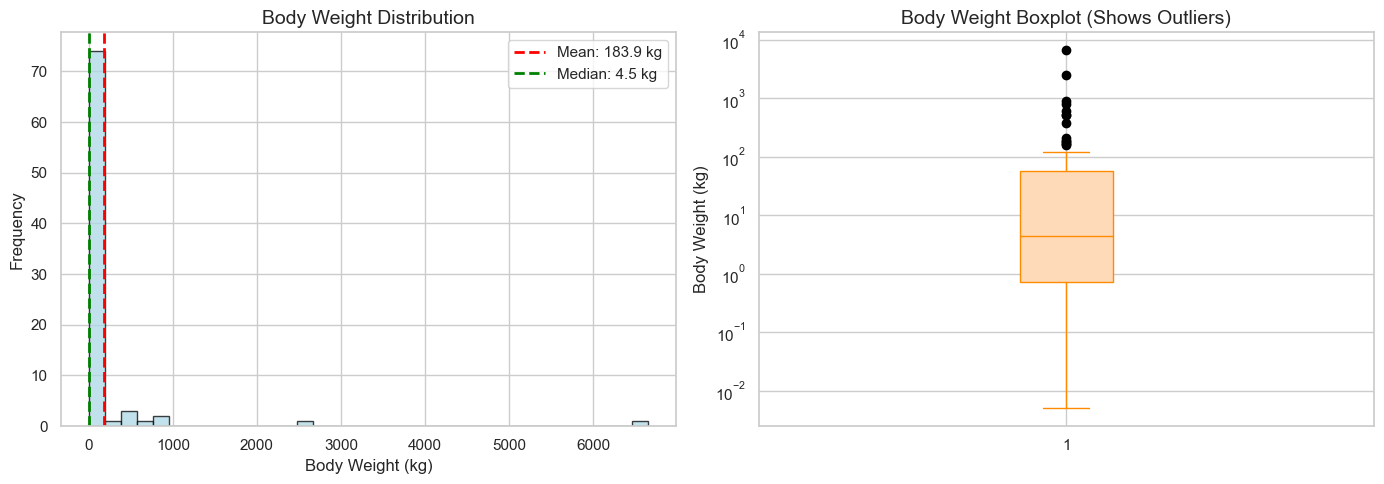

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------------------
# 1️ Histogramme
# ---------------------------------------------------------------------
axes[0].hist(df["bodywt"], bins=35, color="lightblue", edgecolor="black", alpha=0.75)

# Lignes Mean + Median
axes[0].axvline(mean_bw, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_bw:.1f} kg")
axes[0].axvline(median_bw, color="green", linestyle="--", linewidth=2, label=f"Median: {median_bw:.1f} kg")

# Titres + labels
axes[0].set_title("Body Weight Distribution", fontsize=14)
axes[0].set_xlabel("Body Weight (kg)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ---------------------------------------------------------------------
# 2️ Boxplot (avec outliers)
# ---------------------------------------------------------------------
axes[1].boxplot(df["bodywt"], patch_artist=True,
                boxprops=dict(facecolor="peachpuff", color="darkorange"),
                medianprops=dict(color="darkorange"),
                whiskerprops=dict(color="darkorange"),
                capprops=dict(color="darkorange"),
                flierprops=dict(marker='o', markerfacecolor='black', markersize=6)
               )

# Axe Y en log scale
axes[1].set_yscale("log")

# Titres + labels
axes[1].set_title("Body Weight Boxplot (Shows Outliers)", fontsize=14)
axes[1].set_ylabel("Body Weight (kg)")

plt.tight_layout()
plt.show()


In [85]:
# Find outliers

# Report animals identified as outliers
lower = q1 - 1.5 * iqr_bw
upper = q3 + 1.5 * iqr_bw

outliers = df[df["bodywt"] > upper][["name", "bodywt"]] # poids toujours positifs, évidemment pas de lower bound check
print(outliers.sort_values(by="bodywt", ascending=False))


                    name  bodywt
0       African elephant  6654.0
1       Asiatic elephant  2547.0
72          Grizzly bear   899.0
42           Pilot whale   800.0
8                    Cow   600.0
17               Giraffe   529.0
25                 Horse   521.0
77            Polar bear   385.0
20               Gorilla   207.0
75                  Lion   190.0
10                Donkey   187.1
3   Bottle-nosed dolphin   173.5
63          Bengal tiger   162.6
4        Brazilian tapir   160.0


In [86]:
# 1️ Filtrer : retirer les outliers
df_no_outliers = df[(df["bodywt"] >= lower) & (df["bodywt"] <= upper)].copy()
print(df_no_outliers.sort_values(by="bodywt", ascending=False))

                         name genus         vore         order conservation  \
64                 Black bear   Bla     omnivore     Carnivora           lc   
27                     Jaguar   Jag    carnivore     Carnivora           nt   
66                    Caribou   Car    herbivore  Artiodactyla           vu   
41                        Pig   Pig     omnivore  Artiodactyla           lc   
21                  Gray seal   Gra    carnivore     Carnivora           lc   
..                        ...   ...          ...           ...          ...   
35                 Musk shrew   Mus     omnivore   Insectivora           lc   
2               Big brown bat   Big  insectivore    Chiroptera           lc   
34                      Mouse   Mou    herbivore      Rodentia           lc   
30           Little brown bat   Lit  insectivore    Chiroptera           lc   
29  Lesser short-tailed shrew   Les     omnivore   Insectivora           lc   

    sleep_total  sleep_rem  sleep_cycle  awake  bra

In [ ]:



# 2️ Figure en deux colonnes
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Body Weight Distribution (No Outliers)",
                    "Body Weight Boxplot (No Outliers)")
)

# -------------------------------------------------------------------------
# 3️ HISTOGRAMME — Valeurs originales, axe X en logarithmique (comme demandé)
# -------------------------------------------------------------------------
fig.add_trace(
    go.Histogram(
        x=df_no_outliers["bodywt"],
        nbinsx=30,
        marker=dict(color="lightblue", line=dict(width=1, color="black")),
        opacity=0.8
    ),
    row=1, col=1
)

fig.update_xaxes(
    # type="log",
    title_text="Body Weight (kg)",
    row=1, col=1
)
fig.update_yaxes(
    title_text="Frequency",
    row=1, col=1
)

# -------------------------------------------------------------------------
# 4️ BOX PLOT — Sans outliers (comme demandé)
# -------------------------------------------------------------------------
fig.add_trace(
    go.Box(
        y=df_no_outliers["bodywt"],
        boxpoints=False,  # pas d'outliers mais si outliers plotly cherche automatiquement à les afficher
        marker_color="darkorange",
        fillcolor="peachpuff",
        name="Body Weight"
    ),
    row=1, col=2
)

fig.update_yaxes(
    title_text="Body Weight (kg)",
    row=1, col=2
)

# -------------------------------------------------------------------------
# 5️ Mise en forme
# -------------------------------------------------------------------------
fig.update_layout(
    width=1300,
    height=500,
    plot_bgcolor="white",
    showlegend=False
)

fig.show()


In [88]:
df_no_outliers["bodywt"].max()


119.0

### Task 3: Comparative diet analysis

Different dietary strategies may be associated with different energy and rest requirements. The behavioral team hypothesizes that carnivores, herbivores, and omnivores have distinct sleep patterns.

- Calculate mean and median `sleep_total` for each diet type (`vore` column)
- Identify which diet category shows the greatest variability in sleep patterns
- Provide a 2-3 sentence interpretation of what these differences might mean for conservation strategies

In [89]:
# ============================================================================
# TASK 3: COMPARATIVE DIET ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("TASK 3: COMPARATIVE DIET ANALYSIS")
print("="*80)

# Calculate mean, median, std, and count of 'sleep_total' grouped by 'vore'
diet_stats = df.groupby("vore")["sleep_total"].agg(['mean', 'median', 'std', 'count']).reset_index()
print(diet_stats)




TASK 3: COMPARATIVE DIET ANALYSIS
          vore       mean  median       std  count
0    carnivore  10.880000   11.05  4.014788     20
1    herbivore   9.210345    8.40  5.059598     29
2  insectivore  14.087500   13.85  5.120111      8
3     omnivore  11.103846   10.10  2.697033     26


In [ ]:

# Identify diet type with greatest variability and compute its std
fig = px.box(
    df,
    x="vore",
    y="sleep_total",
    title="Sleep Total by Diet Type",
    labels={"vore": "Diet Type", "sleep_total": "Total Sleep (hours)"},
    color="vore",
    color_discrete_sequence=px.colors.qualitative.Pastel
    # px.colors.qualitative.Pastel juste pour des couleurs plus douces
)
fig.show()

Insectivores show the most variable sleep patterns, suggesting diverse metabolic and behavioral strategies within this group. This variability indicates that conservation approaches must be species-specific rather than diet-based.

### Task 4: Percentile analysis

REM sleep is critical for memory consolidation and neural development. The neurobehavioral team wants to understand the distribution of REM sleep across species.

<img src =""/>

- Calculate the 25th, 50th (median), and 75th percentiles for `sleep_rem`
- Determine what percentage of mammals in the dataset experience less than 2 hours of REM sleep per day
- Represent the distribution of `sleep_rem` using a histogram

In [91]:
# ============================================================================
# TASK 4: PERCENTILE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("TASK 4: PERCENTILE ANALYSIS")
print("="*80)

# Remove NaN values for REM sleep analysis
rem= df["sleep_rem"].dropna()
# Calculate percentiles : 25th, 50th, 75th
percentile_25 = rem.quantile(0.25)
percentile_50 = rem.quantile(0.50)
percentile_75 = rem.quantile(0.75)
# Percentage below 2 hours
percentage_below_2_hours = (rem < 2).mean() * 100

print(f"25th Percentile of REM Sleep: {percentile_25:.2f} hours")
print(f"50th Percentile of REM Sleep: {percentile_50:.2f} hours")
print(f"75th Percentile of REM Sleep: {percentile_75:.2f} hours")
print(f"Percentage of species with REM sleep below 2 hours: {percentage_below_2_hours:.2f}%")


TASK 4: PERCENTILE ANALYSIS
25th Percentile of REM Sleep: 1.00 hours
50th Percentile of REM Sleep: 1.90 hours
75th Percentile of REM Sleep: 2.50 hours
Percentage of species with REM sleep below 2 hours: 54.24%


In [92]:
# Plotting the distribution of REM sleep
fig = px.histogram(
    rem,
    x=rem,
    nbins=20,
    title="Distribution of REM Sleep Duration",
    # labels={"rem": "REM Sleep (hours)", "sleep_total": "Number of Species"},
    color_discrete_sequence=["#FF7F0E"]
)
fig.update_layout(bargap=0.1)
fig.show()


54.24% of mammals experience less than 2 hours of REM sleep. Species with very low REM sleep (like elephants and dolphins) may have evolved alternative neural maintenance strategies, requiring specialized conservation attention.

### Task 5: Automated statistical summary function

The research team needs to quickly generate summary statistics for different variables as new data arrives. Build a reusable analysis tool.

- Create a Python function `summary_statistics(dataframe, column_name)` that returns a dictionary containing:
  - mean
  - median
  - mode
  - variance
  - standard deviation
  - IQR
  - minimum
  - maximum
  - count of non-null values
- Apply this function to at least **three different numerical columns** in the dataset
- Display the results in a clean, readable format (consider using a DataFrame or formatted print statements)

In [100]:
# ============================================================================
# TASK 5: AUTOMATED STATISTICAL SUMMARY FUNCTION
# ============================================================================
print("\n" + "="*80)
print("TASK 5: AUTOMATED STATISTICAL SUMMARY FUNCTION")
print("="*80)

def summary_statistics(dataframe, column_name):
    """
    Calculate comprehensive summary statistics for a given column.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        The input dataframe
    column_name : str
        Name of the column to analyze
        
    Returns:
    --------
    dict : Dictionary containing all summary statistics
    """
    
    # Drop NaN values
    data = dataframe[column_name].dropna()
    quantile_1 = data.quantile(0.25)
    quantile_3 = data.quantile(0.75)
    
    # Dictionary to hold statistics: mean, median, mode, variance, std_dev, iqr, min, max, count
    stats_dict = {
        "mean": data.mean(),
        "median": data.median(),
        "mode": data.mode()[0] if not data.mode().empty else np.nan, 
        # handle case with no mode because all values unique
        # np.nan to ensure consistent data type in output
        "variance": data.var(),
        "std_dev": data.std(),
        "iqr": quantile_3 - quantile_1,
        "min": data.min(),
        "max": data.max(),
        "count": data.count()   
       
    }
    
    return stats_dict

# Apply function to three columns

# columns_to_analyze = ['sleep_total', 'bodywt', 'brainwt']
df_test_summary_function_columns_to_analyze = ['Latitude', 'Longitude', 'Depth']

# Store results in a dictionary
# results=pd.DataFrame({column_name: summary_statistics(df_test_summary_function, column_name) for column_name in columns_to_analyze}).T
results=pd.DataFrame({column_name: summary_statistics(df_test_summary_function, column_name) for column_name in df_test_summary_function_columns_to_analyze})
# . T pour transposer afin d'avoir les colonnes comme index
# Display results in a formatted DataFrame


# Alternative: Formatted print
print("\n" + "-"*80)
print("DETAILED SUMMARY STATISTICS")
print("-"*80)
print(results)



TASK 5: AUTOMATED STATISTICAL SUMMARY FUNCTION

--------------------------------------------------------------------------------
DETAILED SUMMARY STATISTICS
--------------------------------------------------------------------------------
              Latitude     Longitude         Depth
mean          1.679033     39.639961     70.767911
median       -3.568500    103.982000     33.000000
mode         -5.902000    126.777000     10.000000
variance    906.803784  15753.251728  15043.488013
std_dev      30.113183    125.511959    122.651898
iqr          44.843750    221.376000     39.477500
min         -77.080000   -179.997000     -1.100000
max          86.005000    179.998000    700.000000
count     23412.000000  23412.000000  23412.000000
